In [1]:
from app.network import load_sumo_network, build_lane_polygons
root, road_file = load_sumo_network('tue-small')
lane_polys = build_lane_polygons(root)

## Interactive Matploblib Viewer (inline, slow)

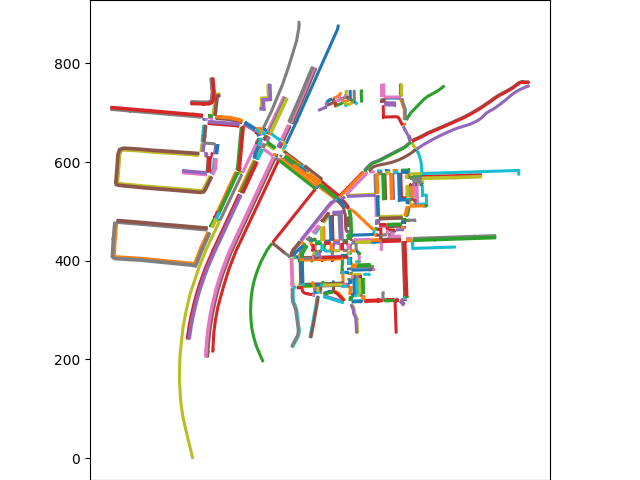

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

for poly in lane_polys:
    x, y = poly.exterior.xy
    y = -np.array(y) # Invert y-axis for correct orientation
    ax.plot(x, y)
    ax.fill(x, y, alpha=0.3)

ax.set_aspect('equal')
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

## Interactive SVG Viewer (opens in external browser)

In [3]:
import webbrowser
import tempfile

polygons = lane_polys

def poly_to_svg(poly, fill="lightblue", stroke="red", stroke_width=0.05):
    pts = " ".join(f"{x},{y}" for x, y in poly.exterior.coords)
    return f'<polygon points="{pts}" fill="{fill}" stroke="{stroke}" stroke-width="{stroke_width}" />'

svg_polygons = "\n".join(poly_to_svg(p) for p in polygons)

html = f"""
<!DOCTYPE html>
<html>
<body style="margin:0">

<svg id="svg" width="100%" height="100%" viewBox="0 0 3 3"
     style="border:1px solid black; cursor: grab;">
  <g id="viewport">
    {svg_polygons}
  </g>
</svg>

<style>
html, body {{
    margin: 0;
    padding: 0;
    width: 100%;
    height: 100%;
    overflow: hidden;
}}

svg {{
    width: 100vw;
    height: 100vh;
    display: block;
}}
</style>

<script>
let svg = document.getElementById("svg");
let viewport = document.getElementById("viewport");

let scale = 1;
let panX = 0;
let panY = 0;

let isDragging = false;
let lastX, lastY;

// Apply transform
function update() {{
    viewport.setAttribute("transform",
        `translate(${{panX}}, ${{panY}}) scale(${{scale}})`
    );
}}

// Zoom with mouse wheel
svg.addEventListener("wheel", (e) => {{
    e.preventDefault();

    const zoomFactor = 1.1;

    const rect = svg.getBoundingClientRect();

    // Zoom center (mouse position relative to SVG)
    const cx = e.clientX - rect.left;
    const cy = e.clientY - rect.top;

    // Convert mouse position to SVG coordinate space
    const viewBox = svg.viewBox.baseVal;
    const svgCx = viewBox.width * (cx / rect.width);
    const svgCy = viewBox.height * (cy / rect.height);

    // World coordinates before zoom
    const worldX = (svgCx - panX) / scale;
    const worldY = (svgCy - panY) / scale;

    // Apply zoom
    const newScale = (e.deltaY < 0) ? scale * zoomFactor : scale / zoomFactor;

    // Recompute pan so center stays fixed
    panX = svgCx - worldX * newScale;
    panY = svgCy - worldY * newScale;

    scale = newScale;

    update();
}});

// Pan with mouse drag
svg.addEventListener("mousedown", (e) => {{
    isDragging = true;
    lastX = e.clientX;
    lastY = e.clientY;
    svg.style.cursor = "grabbing";
}});

const viewBox = svg.viewBox.baseVal;
const svgWidth = svg.clientWidth;
const svgHeight = svg.clientHeight;

svg.addEventListener("mousemove", (e) => {{
    if (!isDragging) return;

    let dx = (e.clientX - lastX) * (viewBox.width / svgWidth);
    let dy = (e.clientY - lastY) * (viewBox.height / svgHeight);

    panX += dx;
    panY += dy;

    lastX = e.clientX;
    lastY = e.clientY;

    update();
}});

svg.addEventListener("mouseup", () => {{
    isDragging = false;
    svg.style.cursor = "grab";
}});

svg.addEventListener("mouseleave", () => {{
    isDragging = false;
    svg.style.cursor = "grab";
}});
</script>

</body>
</html>
"""

tmp = tempfile.NamedTemporaryFile(suffix=".html", delete=False)
with open(tmp.name, "w") as f:
    f.write(html)

webbrowser.open(tmp.name)

True

Opening in existing browser session.
